In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
from src.utils.config import Config, print_config

# ============================================
# IMPORTS ESSENTIELS (PyTorch)
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# Configuration
print_config()
np.random.seed(42)
torch.manual_seed(42)

🔧 CONFIGURATION DU PROJET
🌱 Seed fixée à 42 pour Python, Numpy, PyTorch et cuDNN.
🚀 Device actif : cuda
💻 Nom du GPU : NVIDIA GeForce RTX 3070 Laptop GPU
💾 Mémoire GPU allouée : 0.00 MB
🌱 Seed globale  : 42


# Partie I — MLP et ingénierie PyTorch

Dataset : **Breast Cancer MSK 2018** (données cliniques tabulaires réelles)

## 1. Concepts fondamentaux PyTorch

### 1.1 nn.Module

`nn.Module` est la classe de base de tout modèle PyTorch. Elle encapsule les paramètres
apprenables, les sous-modules, et la méthode `forward()` qui définit la propagation avant.
Tout réseau de neurones hérite de `nn.Module` :

```python
class MonReseau(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(10, 1)
    def forward(self, x): return self.fc(x)
```

### 1.2 Paramètres et gradients

Les **paramètres** (`nn.Parameter`) sont les tenseurs apprenables du modèle — poids $W$
et biais $b$ de chaque couche linéaire. On y accède via `.parameters()` ou
`.named_parameters()`. Leur attribut `.grad` stocke le gradient $\frac{\partial \mathcal{L}}{\partial \theta}$
calculé lors de la rétropropagation.

### 1.3 state_dict

`state_dict()` retourne un `OrderedDict` qui associe le nom de chaque paramètre à son
tenseur de valeurs. C'est le format standard pour sauvegarder et recharger un modèle :
`torch.save(model.state_dict(), 'model.pth')` / `model.load_state_dict(torch.load(...))`.

### 1.4 Device (CPU / GPU)

Le *device* désigne le matériel et la mémoire où s'exécutent les calculs.
Modèle **et** données doivent impérativement être sur le même device :

```python
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
X_batch = X_batch.to(device)
```

### 1.5 Propagation avant & rétropropagation

La **propagation avant** (*forward pass*) applique successivement les transformations
$h^{(l)} = \sigma(W^{(l)} h^{(l-1)} + b^{(l)})$ jusqu'à la sortie.
La **rétropropagation** (*backward pass*) calcule les gradients par la règle de chaîne :
$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial h^{(l)}} \cdot \frac{\partial h^{(l)}}{\partial W^{(l)}}$,
via `loss.backward()`. L'optimiseur met ensuite à jour les paramètres :
$\theta \leftarrow \theta - \eta \nabla_{\theta} \mathcal{L}$.

## 2. Chargement du dataset

In [2]:
import pandas as pd
from pathlib import Path

mlp_df = pd.read_csv("../src/data/raw/breast_msk_2018_clinical_data.tsv", sep="\t")
print(f"Dataset réel : {mlp_df.shape[0]:,} lignes × {mlp_df.shape[1]} colonnes")
mlp_df.head(3)

Dataset réel : 1,918 lignes × 59 colonnes


,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Disease Free Event,Disease Free (Months),ER PCT Primary,ER Status of Sequenced Sample,ER Status of the Primary,...,Sample Type,Sex,Somatic Status,Stage At Diagnosis,Time To Death (Months),TMB (nonsynonymous),Tumor Sample Histology,Tumor Tissue Origin,T Stage,Patient's Vital Status
0,breast_msk_2018,P-0000004,P-0000004-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,1,1.1,70,Positive,Positive,...,Primary,Female,Matched,IV,NaN,0.133333,Breast Invasive Ductal Carcinoma,Breast,T1c,Alive
1,breast_msk_2018,P-0000012,P-0000012-T02-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,0,218.0,0,Negative,Negative,...,Primary,Female,Matched,IIA,NaN,0.033333,Breast Invasive Ductal Carcinoma,Breast,T2,Alive
2,breast_msk_2018,P-0000015,P-0000015-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,1,68.9,90,Positive,Positive,...,Metastasis,Female,Matched,IB,548.0,0.233333,Breast Invasive Ductal Carcinoma,Breast,T1b,Deceased


### 2.1 Génération de données synthétiques (GaussianCopula)

In [3]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=mlp_df)

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(mlp_df)

mlp_df_gan = synthesizer.sample(num_rows=10000)
mlp_df_gan.to_csv('../src/data/raw/synthetic_breastCancer1.csv', index=False)

print(f"Dataset synthétique : {mlp_df_gan.shape}")

c:\Users\ghali\Desktop\DL_project\venv\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\ghali\Desktop\DL_project\venv\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Dataset synthétique : (10000, 59)


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR  = Path("../results/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

def save_excel(df, name):
    df.to_excel(TABLES_DIR / f"{name}.xlsx", index=False)

## 3. Analyse exploratoire (EDA)

### 3.1 Dimensions & types de features

In [5]:
# Colonnes par type
numerical_cols = [
    "Disease Free Event", "Disease Free (Months)", "Fraction Genome Altered",
    "Invasive Carcinoma Diagnosis Age", "Time to Diagnosis Invasive Carcinoma",
    "Last Communication Contact", "Metastatic Recurrence Time", "Mutation Count",
    "NGS Sample Collection Time Period", "Number of Samples Per Patient",
    "Overall Survival (Months)", "Time To Death (Months)", "TMB (nonsynonymous)"
]
categorical_cols = [
    "Cancer Type", "Cancer Type Detailed", "ER Status of Sequenced Sample",
    "ER Status of the Primary", "HER2 IHC Status Primary",
    "HER2 IHC Status of Sequenced Sample", "HER2 Primary Status",
    "Overall HR Status of Sequenced Sample", "Primary Tumor Laterality",
    "Menopausal Status At Diagnosis", "Metastatic Disease at Last Follow-up",
    "Oncotree Code", "Overall HER2 Status of Sequenced Sample",
    "Overall Patient HER2 Status", "Overall Patient HR Status",
    "Overall Patient Receptor Status", "Prior Breast Primary", "Prior Local Recurrence",
    "PR Status of Sequenced Sample", "PR Status of the Primary",
    "Receptor Status Primary", "Site of Sample", "Sample Type", "Sex",
    "Somatic Status", "Tumor Sample Histology", "Tumor Tissue Origin",
    "Patient's Vital Status", "Overall Survival Status"
]
ordinal_cols = [
    "HER2 IHC Score of Sequenced Sample", "HER2 IHC Score Primary",
    "Overall Primary Tumor Grade", "Primary Nuclear Grade",
    "Stage At Diagnosis", "T Stage", "N Stage", "M Stage"
]

numerical_df_gan  = mlp_df_gan[[c for c in numerical_cols  if c in mlp_df_gan.columns]]
categorical_df_gan = mlp_df_gan[[c for c in categorical_cols if c in mlp_df_gan.columns]]
ordinal_df_gan    = mlp_df_gan[[c for c in ordinal_cols    if c in mlp_df_gan.columns]]

print(f"Numerical : {numerical_df_gan.shape[1]} features")
print(f"Categorical: {categorical_df_gan.shape[1]} features")
print(f"Ordinal  : {ordinal_df_gan.shape[1]} features")
save_excel(mlp_df_gan.dtypes.reset_index(), "Features_Types")

Numerical : 13 features
Categorical: 29 features
Ordinal  : 8 features


### 3.2 Distribution de la cible — déséquilibre

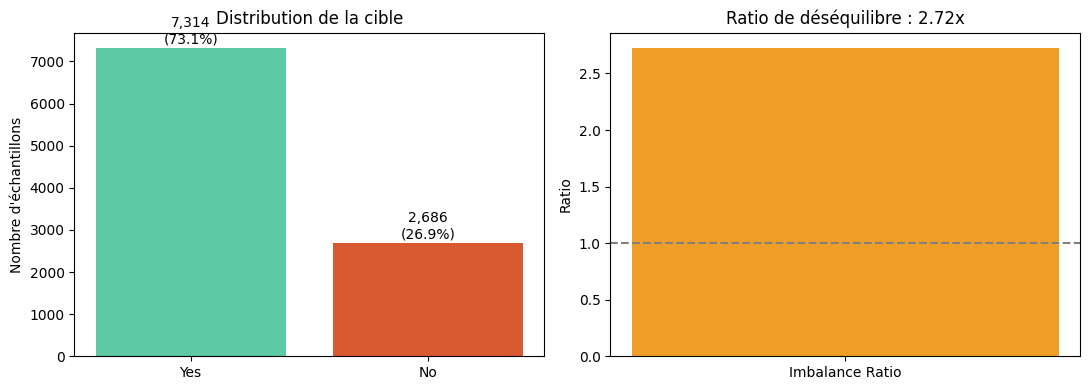


Classe majoritaire (Yes) : 7,314
Classe minoritaire (No)  : 2,686
Ratio déséquilibre       : 2.72x


In [6]:
import matplotlib.pyplot as plt

Y_raw = mlp_df_gan["Metastatic Disease at Last Follow-up"]
counts = Y_raw.value_counts()
imbalance_ratio = counts.max() / counts.min()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=["#5DCAA5", "#D85A30"])
for bar, (k, v) in zip(bars, counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{v:,}\n({v/len(Y_raw)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Distribution de la cible")
axes[0].set_ylabel("Nombre d'échantillons")

# Ratio
axes[1].bar(["Imbalance Ratio"], [imbalance_ratio], color="#EF9F27")
axes[1].axhline(1, color="gray", linestyle="--")
axes[1].set_title(f"Ratio de déséquilibre : {imbalance_ratio:.2f}x")
axes[1].set_ylabel("Ratio")

plt.tight_layout()
save_fig("Target_Distribution")
plt.show()
print(f"\nClasse majoritaire (Yes) : {counts.get('Yes', 0):,}")
print(f"Classe minoritaire (No)  : {counts.get('No',  0):,}")
print(f"Ratio déséquilibre       : {imbalance_ratio:.2f}x")

### 3.3 Statistiques descriptives — features numériques

In [7]:
desc = numerical_df_gan.describe()
print(desc.round(2))
save_excel(desc, "Numerical_Features_Statistics")

       Disease Free Event  Disease Free (Months)  Fraction Genome Altered  \
count            10000.00               10000.00                  9878.00   
mean                 0.73                  42.57                     0.30   
std                  0.44                  51.17                     0.28   
min                  0.00                   0.10                     0.00   
25%                  0.00                   5.60                     0.07   
50%                  1.00                  23.00                     0.22   
75%                  1.00                  61.20                     0.47   
max                  1.00                 367.20                     1.00   

       Invasive Carcinoma Diagnosis Age  Time to Diagnosis Invasive Carcinoma  \
count                          10000.00                              10000.00   
mean                              51.81                                622.70   
std                               12.15                        

### 3.4 Valeurs manquantes

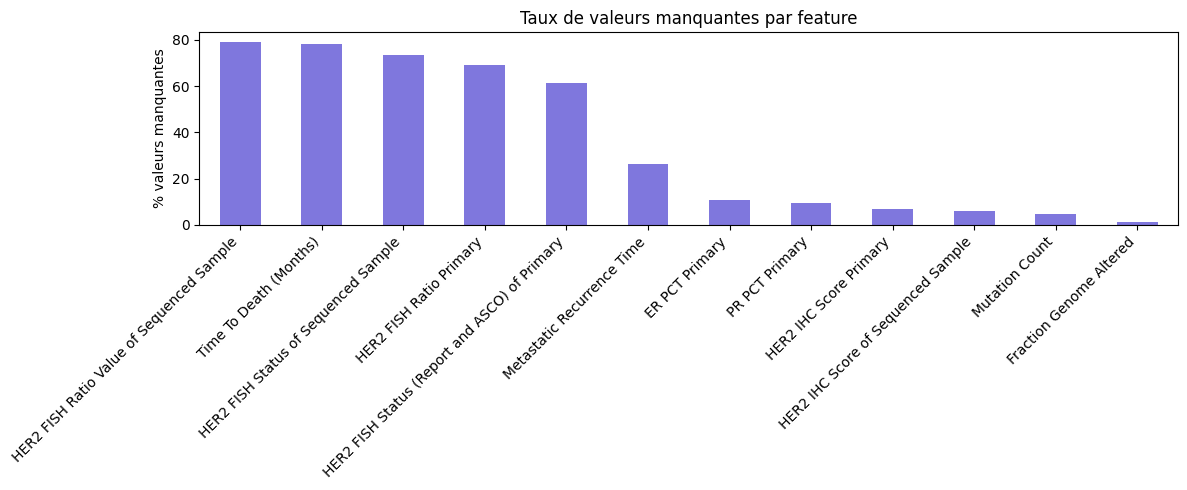

Features avec manquants : 12
Features à supprimer (>40%) : 5


In [8]:
missing_rate = mlp_df_gan.isnull().mean() * 100
missing_nonzero = missing_rate[missing_rate > 0].sort_values(ascending=False)

missing_nonzero.plot(kind="bar", figsize=(12, 5), color="#7F77DD")
plt.ylabel("% valeurs manquantes")
plt.title("Taux de valeurs manquantes par feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig("Missing_Data_Per_Feature")
plt.show()

save_excel(missing_rate.reset_index(), "Missing_Rates_Per_Feature")
print(f"Features avec manquants : {(missing_rate > 0).sum()}")
print(f"Features à supprimer (>40%) : {(missing_rate > 40).sum()}")

### 3.5 Corrélations — features numériques

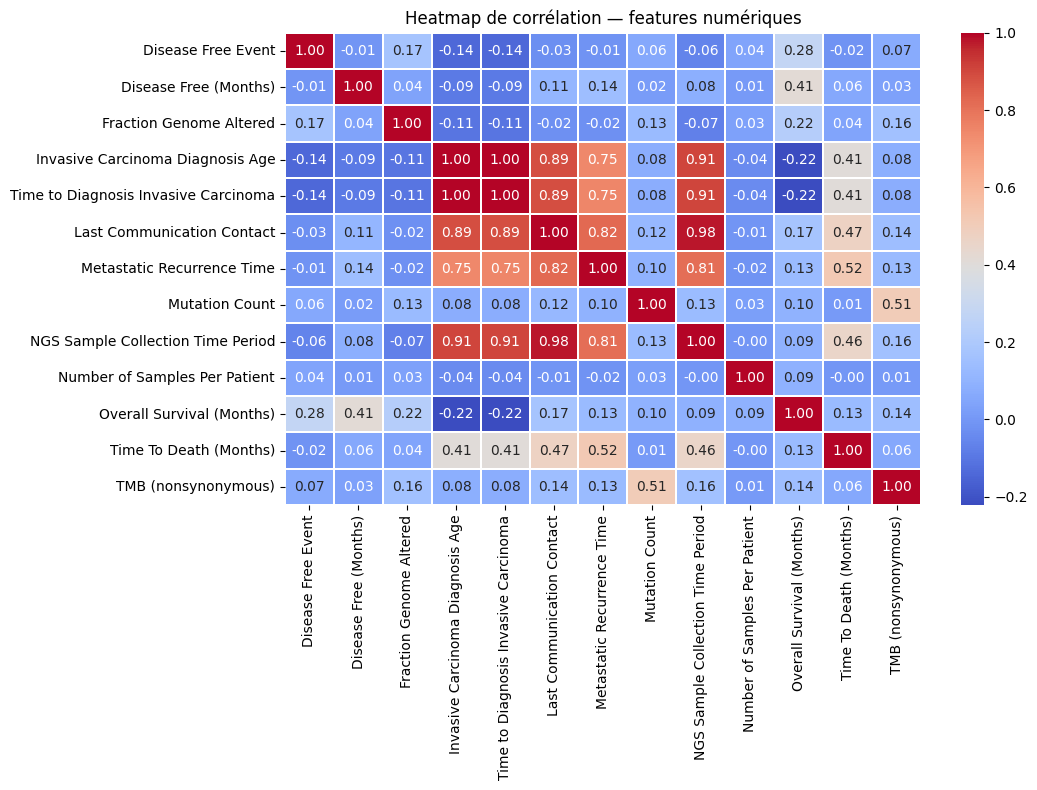

Features parfaitement corrélées (≥ 0.99) :
  Invasive Carcinoma Diagnosis Age  ↔  Time to Diagnosis Invasive Carcinoma


In [9]:
import seaborn as sns

corr = numerical_df_gan.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.3)
plt.title("Heatmap de corrélation — features numériques")
plt.tight_layout()
save_fig("numerical_heatmap")
plt.show()

print("Features parfaitement corrélées (≥ 0.99) :")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.99:
            print(f"  {corr.columns[i]}  ↔  {corr.columns[j]}")

save_excel(corr, "Numerical_Features_Correlation")

### 3.6 Distributions & outliers — features numériques

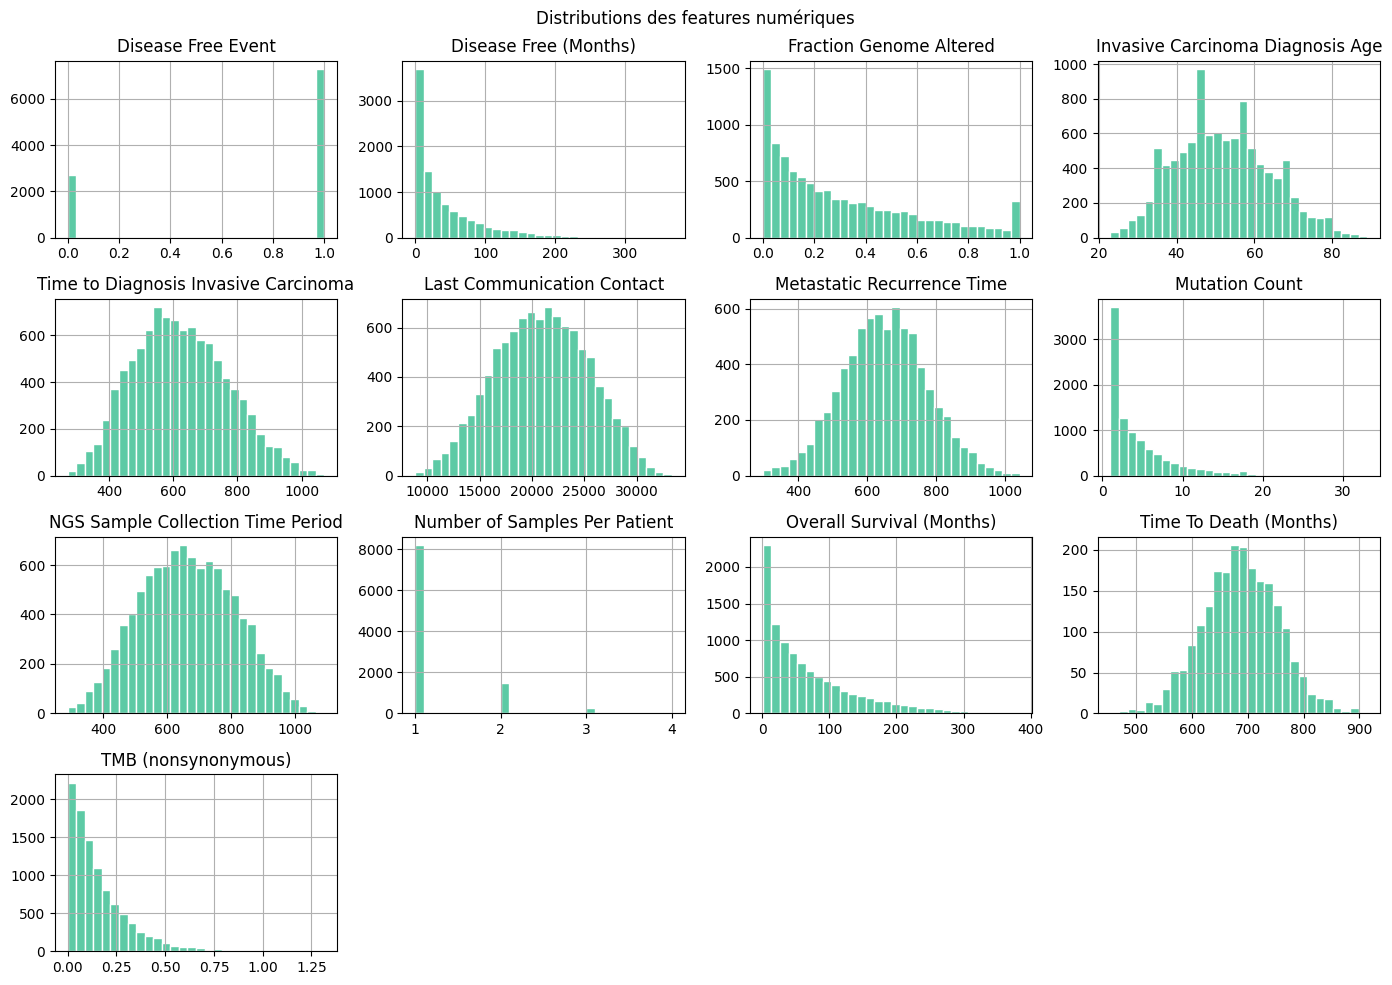

In [10]:
numerical_df_gan.hist(figsize=(14, 10), bins=30, color="#5DCAA5", edgecolor="white")
plt.suptitle("Distributions des features numériques")
plt.tight_layout()
save_fig("Numerical_Features_Distributions")
plt.show()

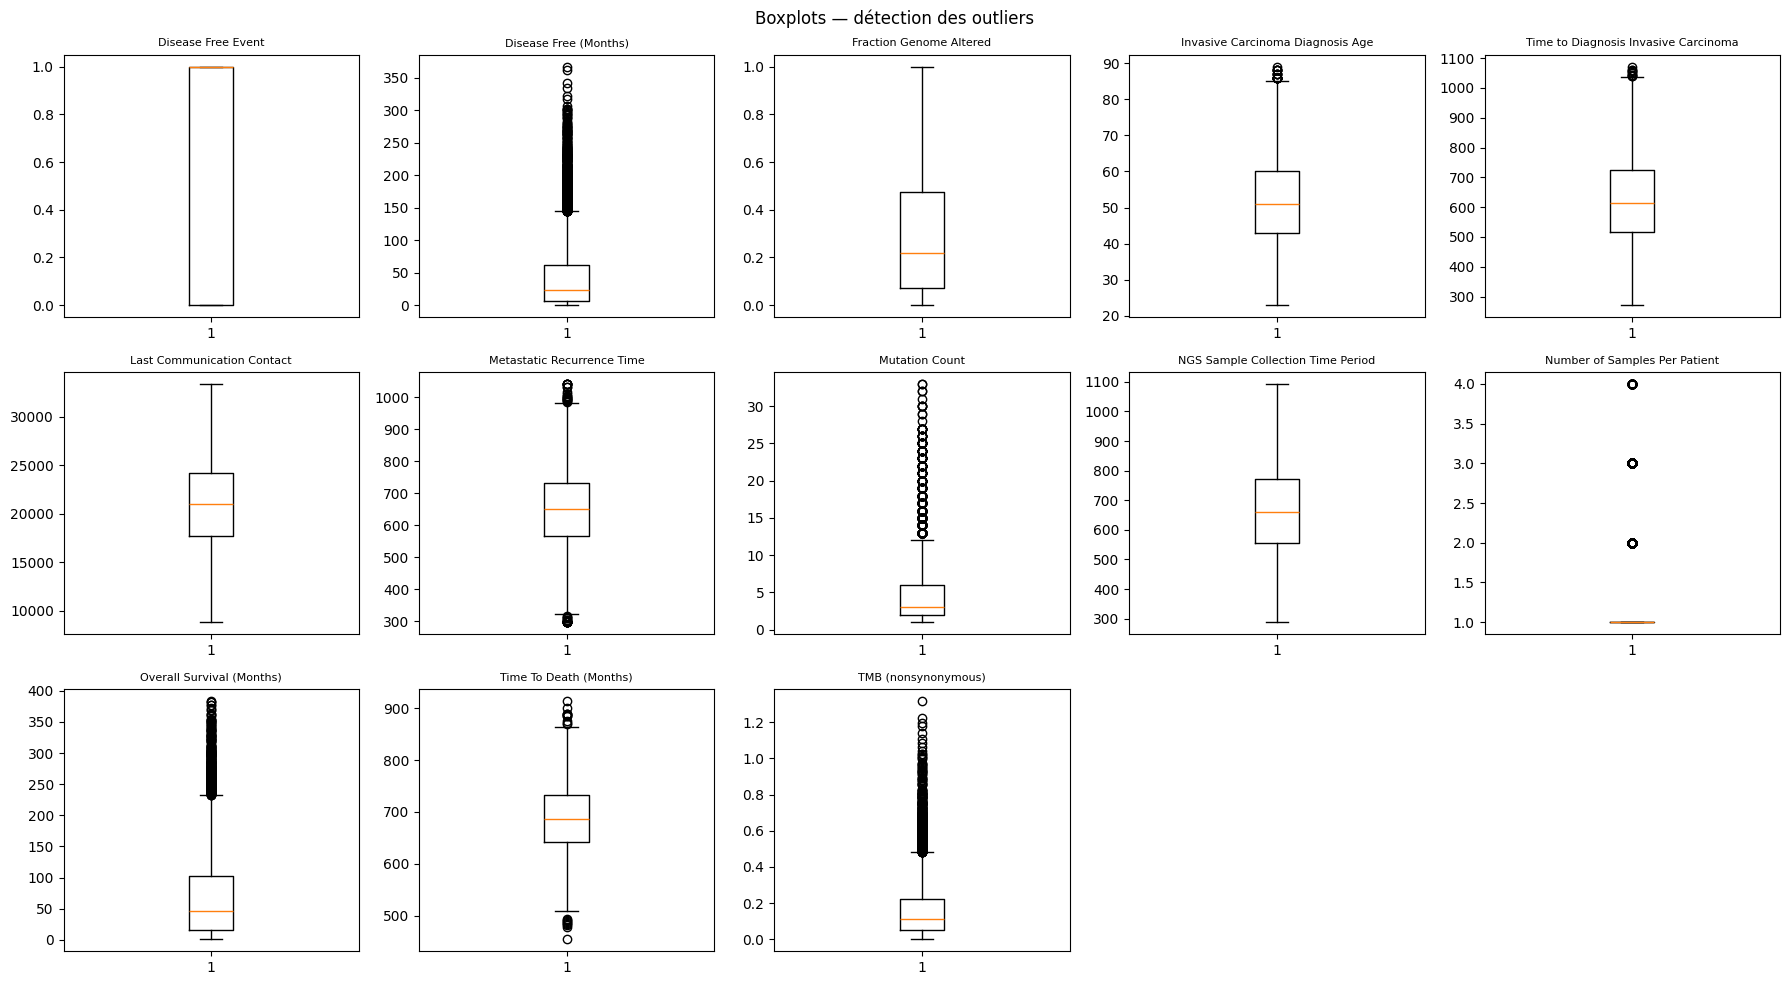

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_df_gan.columns):
    if i < len(axes):
        axes[i].boxplot(numerical_df_gan[col].dropna())
        axes[i].set_title(col, fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.suptitle("Boxplots — détection des outliers")
plt.tight_layout()
save_fig("Boxplots_Numerical")
plt.show()

### 3.7 Distributions — features catégorielles vs cible

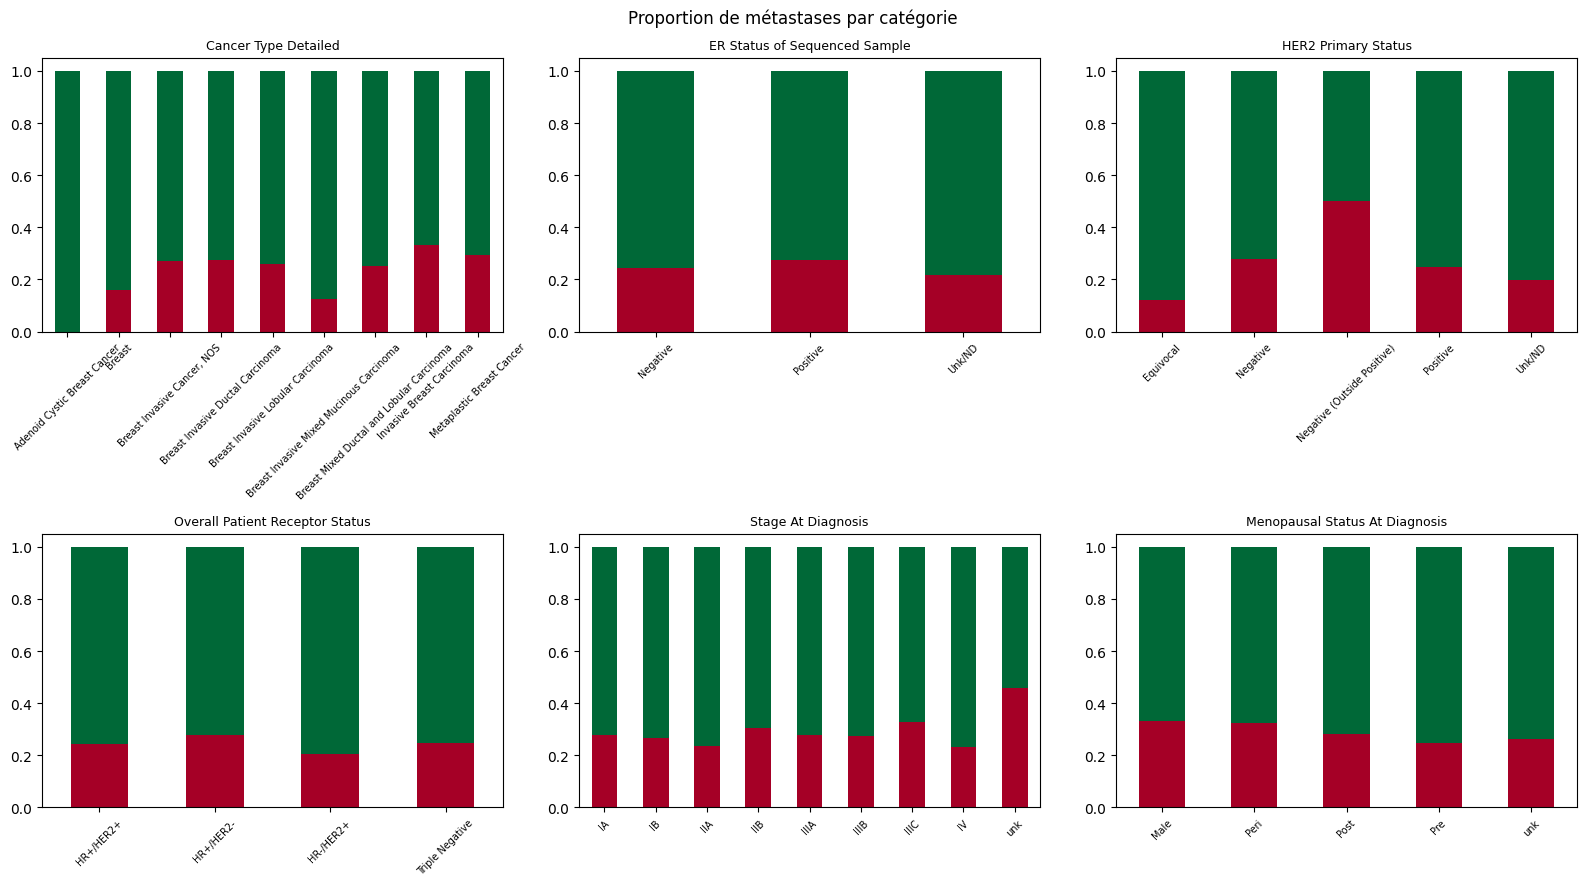

In [12]:
key_cats = [
    "Cancer Type Detailed", "ER Status of Sequenced Sample",
    "HER2 Primary Status", "Overall Patient Receptor Status",
    "Stage At Diagnosis", "Menopausal Status At Diagnosis"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
Y_raw_local = mlp_df_gan["Metastatic Disease at Last Follow-up"]
for ax, col in zip(axes.flatten(), key_cats):
    if col in mlp_df_gan.columns:
        ct = pd.crosstab(mlp_df_gan[col], Y_raw_local, normalize="index")
        ct.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn", legend=False)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("Proportion de métastases par catégorie", fontsize=12)
plt.tight_layout()
save_fig("Categorical_Target_Proportions")
plt.show()

## 4. Préparation des données

### 4.1 Stratégie générale

L'ordre correct du pipeline est :
1. Nettoyage & feature engineering sur le dataset complet
2. **Split** train / val / test
3. Encodage & normalisation fittés **uniquement sur train**, appliqués à val et test

### 4.2 Nettoyage & feature engineering

In [13]:
import numpy as np

# ── 1. Supprimer les colonnes avec > 40% manquants ───────────────────────────
high_missing = [c for c in mlp_df_gan.columns
                if mlp_df_gan[c].isnull().mean() > 0.40]
print("Colonnes supprimées (>40% manquants) :", high_missing)
mlp_df_gan = mlp_df_gan.drop(columns=high_missing)

# ── 2. Feature engineering : ER PCT / PR PCT ─────────────────────────────────
for pct_col, prefix in [("ER PCT Primary", "ER"), ("PR PCT Primary", "PR")]:
    if pct_col in mlp_df_gan.columns:
        col_str = mlp_df_gan[pct_col].astype(str)
        mlp_df_gan[f"{prefix}_PCT_value"] = pd.to_numeric(
            col_str.str.extract(r"(\d+\.?\d*)")[0], errors="coerce")
        mlp_df_gan[f"{prefix}_PCT_intensity"] = (
            col_str.str.extract(r"\((.*?)\)")[0]
            .str.lower().str.strip())
        mlp_df_gan.drop(columns=[pct_col], inplace=True)
        print(f"'{pct_col}' → '{prefix}_PCT_value' + '{prefix}_PCT_intensity'")

# ── 3. Supprimer colonnes ID (aucune valeur prédictive) ──────────────────────
id_cols = ["Study ID", "Patient ID", "Sample ID"]
mlp_df_gan.drop(columns=[c for c in id_cols if c in mlp_df_gan.columns],
                inplace=True)

# ── 4. Supprimer features parfaitement corrélées (redondance) ────────────────
correlated_to_drop = [
    "Mutation Count",                      # parfaitement corrélé avec TMB
    "Time to Diagnosis Invasive Carcinoma",# parfaitement corrélé avec Dx Age
    "Metastatic Recurrence Time",
    "Disease Free (Months)",
    "Overall Survival (Months)",
    "Last Communication Contact",
    "NGS Sample Collection Time Period",
]
mlp_df_gan.drop(
    columns=[c for c in correlated_to_drop if c in mlp_df_gan.columns],
    inplace=True)

print(f"\nDataset après nettoyage : {mlp_df_gan.shape}")
print(f"Valeurs manquantes restantes : {mlp_df_gan.isnull().sum().sum()}")

Colonnes supprimées (>40% manquants) : ['HER2 FISH Status of Sequenced Sample', 'HER2 FISH Ratio Value of Sequenced Sample', 'HER2 FISH Ratio Primary', 'HER2 FISH Status (Report and ASCO) of Primary', 'Time To Death (Months)']
'ER PCT Primary' → 'ER_PCT_value' + 'ER_PCT_intensity'
'PR PCT Primary' → 'PR_PCT_value' + 'PR_PCT_intensity'

Dataset après nettoyage : (10000, 46)
Valeurs manquantes restantes : 23342


### 4.3 Imputation des valeurs manquantes

In [14]:
# Numérique → médiane
num_cols_present = [c for c in mlp_df_gan.select_dtypes(include="number").columns
                    if c != "Metastatic Disease at Last Follow-up"]
for col in num_cols_present:
    if mlp_df_gan[col].isnull().any():
        mlp_df_gan[col].fillna(mlp_df_gan[col].median(), inplace=True)

# Catégoriel / ordinal → mode
cat_cols_present = mlp_df_gan.select_dtypes(include="object").columns.tolist()
for col in cat_cols_present:
    if mlp_df_gan[col].isnull().any():
        mlp_df_gan[col].fillna(mlp_df_gan[col].mode().iloc[0], inplace=True)

print("Valeurs manquantes après imputation :", mlp_df_gan.isnull().sum().sum())

Valeurs manquantes après imputation : 0


C:\Users\ghali\AppData\Local\Temp\ipykernel_17668\754579195.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mlp_df_gan[col].fillna(mlp_df_gan[col].median(), inplace=True)
C:\Users\ghali\AppData\Local\Temp\ipykernel_17668\754579195.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

### 4.4 Split train / val / test — AVANT encodage

In [15]:
from sklearn.model_selection import train_test_split

X = mlp_df_gan.drop(columns=["Metastatic Disease at Last Follow-up"])
Y = mlp_df_gan["Metastatic Disease at Last Follow-up"]

# 70% train / 15% val / 15% test — stratifié sur Y
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=42, stratify=Y_temp)

print(f"Train : {X_train.shape[0]:,} | Val : {X_val.shape[0]:,} | Test : {X_test.shape[0]:,}")

# Cible binaire
Y_train_enc = Y_train.map({"No": 0, "Yes": 1})
Y_val_enc   = Y_val.map({"No": 0, "Yes": 1})
Y_test_enc  = Y_test.map({"No": 0, "Yes": 1})

Train : 7,000 | Val : 1,500 | Test : 1,500


### 4.5 Encodage & normalisation (fittés sur train uniquement)

In [16]:
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder, RobustScaler, QuantileTransformer

X_train_enc = X_train.copy()
X_val_enc   = X_val.copy()
X_test_enc  = X_test.copy()

# ── Target encoding pour les catégoriels (haute cardinalité) ─────────────────
cat_cols_to_encode = X_train.select_dtypes(include="object").columns.tolist()
if cat_cols_to_encode:
    te = TargetEncoder()
    X_train_enc[cat_cols_to_encode] = te.fit_transform(
        X_train[cat_cols_to_encode], Y_train_enc)
    X_val_enc[cat_cols_to_encode]   = te.transform(X_val[cat_cols_to_encode])
    X_test_enc[cat_cols_to_encode]  = te.transform(X_test[cat_cols_to_encode])
    print(f"Target encoding : {len(cat_cols_to_encode)} colonnes")

# ── Log-transform + RobustScaler pour features très skewées ──────────────────
skewed_features = [c for c in [
    "TMB (nonsynonymous)", "Mutation Count", "Fraction Genome Altered",
    "Number of Samples Per Patient"
] if c in X_train_enc.columns]

for df in [X_train_enc, X_val_enc, X_test_enc]:
    df[skewed_features] = np.log1p(df[skewed_features].clip(lower=0))

rs = RobustScaler()
X_train_enc[skewed_features] = rs.fit_transform(X_train_enc[skewed_features])
X_val_enc[skewed_features]   = rs.transform(X_val_enc[skewed_features])
X_test_enc[skewed_features]  = rs.transform(X_test_enc[skewed_features])
print(f"RobustScaler (log) : {skewed_features}")

# ── QuantileTransformer pour les features de durée ────────────────────────────
time_features = [c for c in [
    "Invasive Carcinoma Diagnosis Age",
    "Disease Free Event", "ER_PCT_value", "PR_PCT_value"
] if c in X_train_enc.columns]

if time_features:
    qt = QuantileTransformer(output_distribution="normal", random_state=42)
    X_train_enc[time_features] = qt.fit_transform(X_train_enc[time_features])
    X_val_enc[time_features]   = qt.transform(X_val_enc[time_features])
    X_test_enc[time_features]  = qt.transform(X_test_enc[time_features])
    print(f"QuantileTransformer : {time_features}")

# ── Vérification finale ───────────────────────────────────────────────────────
assert X_train_enc.isnull().sum().sum() == 0, "NaN restants dans X_train_enc !"
print(f"\nDimension finale des features : {X_train_enc.shape[1]}")
print("Aucune valeur manquante — OK")

Target encoding : 38 colonnes
RobustScaler (log) : ['TMB (nonsynonymous)', 'Fraction Genome Altered', 'Number of Samples Per Patient']
QuantileTransformer : ['Invasive Carcinoma Diagnosis Age', 'Disease Free Event', 'ER_PCT_value', 'PR_PCT_value']

Dimension finale des features : 45
Aucune valeur manquante — OK


### 4.6 Conversion en tenseurs PyTorch & mise sur device

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

X_train_t = torch.tensor(X_train_enc.values, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_enc.values,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_enc.values,  dtype=torch.float32)

Y_train_t = torch.tensor(Y_train_enc.values, dtype=torch.float32).unsqueeze(1)
Y_val_t   = torch.tensor(Y_val_enc.values,   dtype=torch.float32).unsqueeze(1)
Y_test_t  = torch.tensor(Y_test_enc.values,  dtype=torch.float32).unsqueeze(1)

# pos_weight pour gérer le déséquilibre (feedback prof : skewed data)
n_neg = (Y_train_t == 0).sum().float()
n_pos = (Y_train_t == 1).sum().float()
pos_weight = (n_neg / n_pos).clamp(max=5.0)
print(f"pos_weight (skewed data) : {pos_weight.item():.3f}")

train_ds = TensorDataset(X_train_t, Y_train_t)
val_ds   = TensorDataset(X_val_t,   Y_val_t)
test_ds  = TensorDataset(X_test_t,  Y_test_t)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

input_dim = X_train_t.shape[1]
print(f"input_dim : {input_dim}")

Device utilisé : cuda
pos_weight (skewed data) : 0.367
input_dim : 45


## 5. Implémentation des MLP

### 5.1 Différence nn.Sequential vs classe personnalisée

| Critère | `nn.Sequential` | Classe `nn.Module` |
|---|---|---|
| Syntaxe | Liste ordonnée de couches | `__init__` + `forward()` explicite |
| Flexibilité | Flux linéaire uniquement | Skip connections, branches, attention |
| Inspection | `.named_parameters()` simple | Idem + logique conditionnelle possible |
| Usage recommandé | Prototypage rapide | Architectures complexes ou personnalisées |

### 5.2 Version nn.Sequential

In [18]:
model_Sequential = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),

    nn.Linear(32, 1)    # logit brut → BCEWithLogitsLoss
).to(device)

print(f"Sequential — {sum(p.numel() for p in model_Sequential.parameters()):,} paramètres")

Sequential — 16,705 paramètres


### 5.3 Version classe personnalisée (nn.Module)

In [19]:
class PersonnalizedMLP(nn.Module):
    """MLP personnalisé pour classification binaire tabulaire.
    
    Architecture : 128 → 64 → 32 → 1
    BatchNorm après chaque couche cachée pour stabiliser l'entraînement.
    Dropout pour régularisation.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.fc1      = nn.Linear(input_dim, 128)
        self.bn1      = nn.BatchNorm1d(128)
        self.drop1    = nn.Dropout(0.3)

        self.fc2      = nn.Linear(128, 64)
        self.bn2      = nn.BatchNorm1d(64)
        self.drop2    = nn.Dropout(0.2)

        self.fc3      = nn.Linear(64, 32)
        self.bn3      = nn.BatchNorm1d(32)

        self.out      = nn.Linear(32, 1)

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.bn2(self.fc2(x))))
        x = torch.relu(self.bn3(self.fc3(x)))
        return self.out(x)   # logit — pas de sigmoid ici

model_Functional = PersonnalizedMLP(input_dim=input_dim).to(device)
print(f"Personnalisé — {sum(p.numel() for p in model_Functional.parameters()):,} paramètres")

Personnalisé — 16,705 paramètres


## 6. Inspection des paramètres

In [20]:
print("=" * 60)
print("named_parameters() — nn.Sequential")
print("=" * 60)
for name, param in model_Sequential.named_parameters():
    print(f"  {name:30s} | shape: {tuple(param.shape)} | requires_grad: {param.requires_grad}")

print("\nstate_dict() keys :")
for key, val in model_Sequential.state_dict().items():
    print(f"  {key:30s} | {val.shape}")

named_parameters() — nn.Sequential
  0.weight                       | shape: (128, 45) | requires_grad: True
  0.bias                         | shape: (128,) | requires_grad: True
  1.weight                       | shape: (128,) | requires_grad: True
  1.bias                         | shape: (128,) | requires_grad: True
  4.weight                       | shape: (64, 128) | requires_grad: True
  4.bias                         | shape: (64,) | requires_grad: True
  5.weight                       | shape: (64,) | requires_grad: True
  5.bias                         | shape: (64,) | requires_grad: True
  8.weight                       | shape: (32, 64) | requires_grad: True
  8.bias                         | shape: (32,) | requires_grad: True
  9.weight                       | shape: (32,) | requires_grad: True
  9.bias                         | shape: (32,) | requires_grad: True
  11.weight                      | shape: (1, 32) | requires_grad: True
  11.bias                        | shap

In [21]:
print("=" * 60)
print("named_parameters() — PersonnalizedMLP")
print("=" * 60)
for name, param in model_Functional.named_parameters():
    print(f"  {name:20s} | shape: {tuple(param.shape)}")

print("\nstate_dict() keys :")
for key in model_Functional.state_dict().keys():
    print(f"  {key}")

named_parameters() — PersonnalizedMLP
  fc1.weight           | shape: (128, 45)
  fc1.bias             | shape: (128,)
  bn1.weight           | shape: (128,)
  bn1.bias             | shape: (128,)
  fc2.weight           | shape: (64, 128)
  fc2.bias             | shape: (64,)
  bn2.weight           | shape: (64,)
  bn2.bias             | shape: (64,)
  fc3.weight           | shape: (32, 64)
  fc3.bias             | shape: (32,)
  bn3.weight           | shape: (32,)
  bn3.bias             | shape: (32,)
  out.weight           | shape: (1, 32)
  out.bias             | shape: (1,)

state_dict() keys :
  fc1.weight
  fc1.bias
  bn1.weight
  bn1.bias
  bn1.running_mean
  bn1.running_var
  bn1.num_batches_tracked
  fc2.weight
  fc2.bias
  bn2.weight
  bn2.bias
  bn2.running_mean
  bn2.running_var
  bn2.num_batches_tracked
  fc3.weight
  fc3.bias
  bn3.weight
  bn3.bias
  bn3.running_mean
  bn3.running_var
  bn3.num_batches_tracked
  out.weight
  out.bias


## 7. Stratégies d'initialisation

| Stratégie | Formule | Quand l'utiliser |
|---|---|---|
| Gaussienne | $W \sim \mathcal{N}(0, \sigma^2)$ | Baseline générique |
| Constante | $W = c$ | Rarement utile (brise la symétrie seulement si $c \neq 0$) |
| Xavier | $W \sim \mathcal{U}(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \cdots)$ | Activations sigmoid/tanh |
| He (Kaiming) | $W \sim \mathcal{N}(0, \frac{2}{n_{in}})$ | Activations ReLU ← **notre cas** |

In [22]:
def init_gaussian(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=0.02)
        nn.init.zeros_(m.bias)

def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.01)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

def init_he(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        nn.init.zeros_(m.bias)

init_strategies = {
    "gaussian": init_gaussian,
    "constant": init_constant,
    "xavier":   init_xavier,
    "he":       init_he
}

### 7.1 Comparaison des initialisations — PersonnalizedMLP

In [23]:
from sklearn.metrics import roc_auc_score

INIT_EPOCHS = 20
results_init_Functional = {}
best_val_auc_Functional = 0.0
best_state_Functional   = None
best_init_Functional    = None

criterion_init = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device))

for init_name, init_fn in init_strategies.items():
    # Réinitialiser le modèle avec cette stratégie
    model_tmp = PersonnalizedMLP(input_dim=input_dim).to(device)
    model_tmp.apply(init_fn)

    opt_tmp = torch.optim.Adam(model_tmp.parameters(), lr=1e-3)

    for epoch in range(INIT_EPOCHS):
        model_tmp.train()
        for X_b, Y_b in train_loader:
            X_b, Y_b = X_b.to(device), Y_b.to(device)
            opt_tmp.zero_grad()
            loss = criterion_init(model_tmp(X_b), Y_b)
            loss.backward()
            opt_tmp.step()

    # Évaluation sur val
    model_tmp.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_b, Y_b in val_loader:
            probs = torch.sigmoid(model_tmp(X_b.to(device))).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(Y_b.numpy().flatten())

    val_auc = roc_auc_score(all_labels, all_probs)
    results_init_Functional[init_name] = round(val_auc, 4)
    print(f"  {init_name:10s} → Val AUC : {val_auc:.4f}")

    if val_auc > best_val_auc_Functional:
        best_val_auc_Functional = val_auc
        best_state_Functional   = model_tmp.state_dict()
        best_init_Functional    = init_name

print(f"\nMeilleure init (Functional) : {best_init_Functional} | AUC = {best_val_auc_Functional:.4f}")

  gaussian   → Val AUC : 0.7509
  constant   → Val AUC : 0.7033
  xavier     → Val AUC : 0.7469
  he         → Val AUC : 0.7494

Meilleure init (Functional) : gaussian | AUC = 0.7509


### 7.2 Comparaison des initialisations — nn.Sequential

In [24]:
results_init_Sequential = {}
best_val_auc_Sequential = 0.0
best_state_Sequential   = None
best_init_Sequential    = None

for init_name, init_fn in init_strategies.items():
    model_tmp_seq = nn.Sequential(
        nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)
    model_tmp_seq.apply(init_fn)

    opt_tmp = torch.optim.Adam(model_tmp_seq.parameters(), lr=1e-3)

    for epoch in range(INIT_EPOCHS):
        model_tmp_seq.train()
        for X_b, Y_b in train_loader:
            X_b, Y_b = X_b.to(device), Y_b.to(device)
            opt_tmp.zero_grad()
            loss = criterion_init(model_tmp_seq(X_b), Y_b)
            loss.backward()
            opt_tmp.step()

    model_tmp_seq.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_b, Y_b in val_loader:
            probs = torch.sigmoid(model_tmp_seq(X_b.to(device))).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(Y_b.numpy().flatten())

    val_auc = roc_auc_score(all_labels, all_probs)
    results_init_Sequential[init_name] = round(val_auc, 4)
    print(f"  {init_name:10s} → Val AUC : {val_auc:.4f}")

    if val_auc > best_val_auc_Sequential:
        best_val_auc_Sequential = val_auc
        best_state_Sequential   = model_tmp_seq.state_dict()
        best_init_Sequential    = init_name

print(f"\nMeilleure init (Sequential) : {best_init_Sequential} | AUC = {best_val_auc_Sequential:.4f}")

  gaussian   → Val AUC : 0.7491
  constant   → Val AUC : 0.7204
  xavier     → Val AUC : 0.7477
  he         → Val AUC : 0.7465

Meilleure init (Sequential) : gaussian | AUC = 0.7491


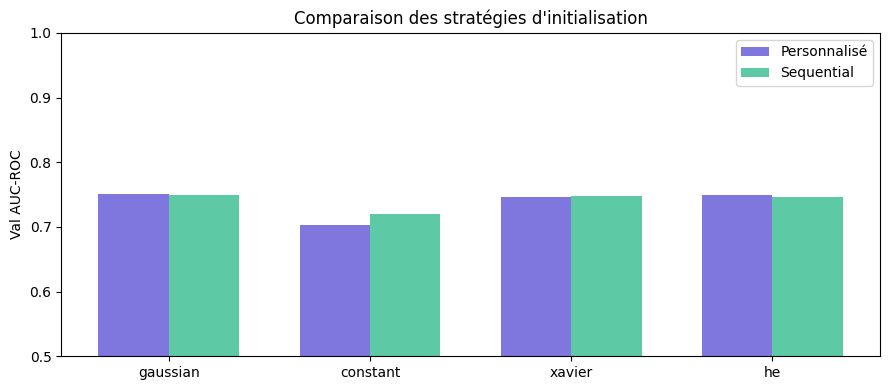

In [25]:
# Visualisation comparative
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
x      = list(results_init_Functional.keys())
auc_f  = list(results_init_Functional.values())
auc_s  = list(results_init_Sequential.values())
width  = 0.35
xs     = range(len(x))

bars1 = ax.bar([i - width/2 for i in xs], auc_f, width, label="Personnalisé", color="#7F77DD")
bars2 = ax.bar([i + width/2 for i in xs], auc_s, width, label="Sequential",   color="#5DCAA5")
ax.set_xticks(list(xs)); ax.set_xticklabels(x)
ax.set_ylabel("Val AUC-ROC")
ax.set_title("Comparaison des stratégies d'initialisation")
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
save_fig("Initialisation_Comparison")
plt.show()

## 8. Sauvegarde & rechargement du meilleur modèle

In [26]:
from pathlib import Path

SAVE_DIR = Path("../src/models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Sauvegarder les meilleurs state_dicts
torch.save(best_state_Functional,
           SAVE_DIR / f"best_mlp_functional_{best_init_Functional}.pth")
torch.save(best_state_Sequential,
           SAVE_DIR / f"best_mlp_sequential_{best_init_Sequential}.pth")

print(f"Functional sauvegardé : best_mlp_functional_{best_init_Functional}.pth")
print(f"Sequential sauvegardé : best_mlp_sequential_{best_init_Sequential}.pth")

Functional sauvegardé : best_mlp_functional_gaussian.pth
Sequential sauvegardé : best_mlp_sequential_gaussian.pth


In [27]:
# Rechargement + vérification
model_Functional = PersonnalizedMLP(input_dim=input_dim).to(device)
model_Functional.load_state_dict(
    torch.load(SAVE_DIR / f"best_mlp_functional_{best_init_Functional}.pth",
               map_location=device)
)
model_Functional.eval()
print("Rechargement PersonnalizedMLP : OK")

model_Sequential = nn.Sequential(
    nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.ReLU(),
    nn.Linear(32, 1)
).to(device)
model_Sequential.load_state_dict(
    torch.load(SAVE_DIR / f"best_mlp_sequential_{best_init_Sequential}.pth",
               map_location=device)
)
model_Sequential.eval()
print("Rechargement Sequential : OK")

Rechargement PersonnalizedMLP : OK
Rechargement Sequential : OK


C:\Users\ghali\AppData\Local\Temp\ipykernel_17668\3480514013.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(SAVE_DIR / f"best_mlp_functional_{best_init_Funct

## 9. Entraînement final (150 epochs) avec DataLoader

In [28]:
def train_mlp(model, model_name, train_loader, val_loader,
               epochs=150, lr=1e-3, pos_weight=None):
    """Boucle d'entraînement générique pour MLP binaire.
    
    Utilise DataLoader (mini-batches) — jamais full-batch sur 10k samples.
    Retourne history dict avec train_loss, val_loss par epoch.
    """
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(device) if pos_weight is not None else None)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10, verbose=False)

    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    best_val_loss = float("inf")

    for epoch in range(epochs):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        t_loss = 0.0
        for X_b, Y_b in train_loader:
            X_b, Y_b = X_b.to(device), Y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), Y_b)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        # ── Val ──────────────────────────────────────────────────────────────
        model.eval()
        v_loss, all_p, all_l = 0.0, [], []
        with torch.no_grad():
            for X_b, Y_b in val_loader:
                X_b, Y_b = X_b.to(device), Y_b.to(device)
                logits = model(X_b)
                v_loss += criterion(logits, Y_b).item()
                all_p.extend(torch.sigmoid(logits).cpu().numpy().flatten())
                all_l.extend(Y_b.cpu().numpy().flatten())

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        try:
            val_auc = roc_auc_score(all_l, all_p)
        except Exception:
            val_auc = 0.0

        scheduler.step(avg_v)
        history["train_loss"].append(avg_t)
        history["val_loss"].append(avg_v)
        history["val_auc"].append(val_auc)

        if avg_v < best_val_loss:
            best_val_loss = avg_v
            torch.save(model.state_dict(), SAVE_DIR / f"trained_{model_name}.pth")

        if (epoch + 1) % 25 == 0:
            print(f"[{model_name}] Epoch {epoch+1:03d} | "
                  f"Train: {avg_t:.4f} | Val: {avg_v:.4f} | AUC: {val_auc:.4f}")

    return history

In [29]:
# Appliquer la meilleure init avant l'entraînement final
model_Functional.apply(init_strategies[best_init_Functional])
model_Sequential.apply(init_strategies[best_init_Sequential])

history_Functional = train_mlp(
    model_Functional, "functional", train_loader, val_loader,
    epochs=150, pos_weight=pos_weight)

history_Sequential = train_mlp(
    model_Sequential, "sequential", train_loader, val_loader,
    epochs=150, pos_weight=pos_weight)

c:\Users\ghali\Desktop\DL_project\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[functional] Epoch 025 | Train: 0.2981 | Val: 0.3204 | AUC: 0.7482
[functional] Epoch 050 | Train: 0.2915 | Val: 0.3213 | AUC: 0.7474
[functional] Epoch 075 | Train: 0.2898 | Val: 0.3247 | AUC: 0.7457
[functional] Epoch 100 | Train: 0.2877 | Val: 0.3263 | AUC: 0.7450
[functional] Epoch 125 | Train: 0.2863 | Val: 0.3265 | AUC: 0.7450
[functional] Epoch 150 | Train: 0.2876 | Val: 0.3253 | AUC: 0.7449


c:\Users\ghali\Desktop\DL_project\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[sequential] Epoch 025 | Train: 0.2998 | Val: 0.3232 | AUC: 0.7436
[sequential] Epoch 050 | Train: 0.2897 | Val: 0.3257 | AUC: 0.7432
[sequential] Epoch 075 | Train: 0.2858 | Val: 0.3300 | AUC: 0.7412
[sequential] Epoch 100 | Train: 0.2828 | Val: 0.3300 | AUC: 0.7407
[sequential] Epoch 125 | Train: 0.2828 | Val: 0.3318 | AUC: 0.7408
[sequential] Epoch 150 | Train: 0.2831 | Val: 0.3309 | AUC: 0.7405


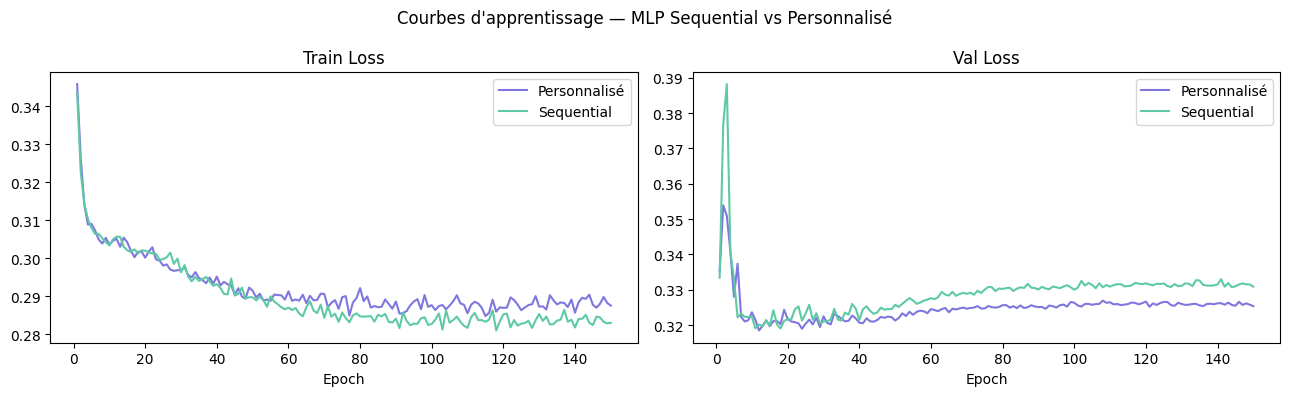

In [30]:
# Courbes de loss comparatives
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hist, label, color in [
    (history_Functional, "Personnalisé", "#7F77DD"),
    (history_Sequential, "Sequential",  "#5DCAA5")
]:
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"], color=color, label=label)
    axes[1].plot(ep, hist["val_loss"],   color=color, label=label)

axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Val Loss");   axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("Courbes d'apprentissage — MLP Sequential vs Personnalisé", fontsize=12)
plt.tight_layout()
save_fig("Learning_Curves_MLP")
plt.show()

## 10. XGBoost — comparaison avec le MLP
XGBoost est un ensemble de gradient boosting qui gère nativement
le déséquilibre via `scale_pos_weight`, sans nécessiter de normalisation.

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import numpy as np

# scale_pos_weight = n_neg / n_pos (équivalent du pos_weight PyTorch)
n_neg_xgb = (Y_train_enc == 0).sum()
n_pos_xgb = (Y_train_enc == 1).sum()
spw = n_neg_xgb / n_pos_xgb
print(f"scale_pos_weight XGBoost : {spw:.3f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_enc, Y_train_enc,
    eval_set=[(X_val_enc, Y_val_enc)],
    verbose=False
)

xgb_probs = xgb_model.predict_proba(X_test_enc)[:, 1]
xgb_preds = (xgb_probs > 0.5).astype(int)

xgb_auc = roc_auc_score(Y_test_enc, xgb_probs)
xgb_f1  = f1_score(Y_test_enc, xgb_preds)
xgb_acc = accuracy_score(Y_test_enc, xgb_preds)

print(f"XGBoost — AUC : {xgb_auc:.4f} | F1 : {xgb_f1:.4f} | Acc : {xgb_acc:.4f}")

scale_pos_weight XGBoost : 0.367


c:\Users\ghali\Desktop\DL_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:46:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost — AUC : 0.7437 | F1 : 0.8115 | Acc : 0.7287


## 11. Évaluation finale sur le Test Set — comparaison des 3 modèles

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)

# ── Reset index pour garantir l'alignement avec les prédictions ───────────────
# Y_test_enc peut avoir un index non-continu après train_test_split
Y_test_np = Y_test_enc.reset_index(drop=True).to_numpy().astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# Collecte des prédictions sur le test set (via DataLoader — pas de squeeze)
# ─────────────────────────────────────────────────────────────────────────────
def get_test_predictions(model, test_loader, device):
    """Retourne (probs, preds) sur le test set complet via DataLoader."""
    model.eval()
    all_probs, all_preds = [], []
    with torch.no_grad():
        for X_b, _ in test_loader:
            X_b    = X_b.to(device)
            logits = model(X_b)
            probs  = torch.sigmoid(logits).cpu().numpy().flatten()
            preds  = (probs > 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
    return np.array(all_probs), np.array(all_preds)

# Recharger les meilleurs checkpoints
model_Functional.load_state_dict(
    torch.load(SAVE_DIR / "trained_functional.pth", map_location=device))
model_Sequential.load_state_dict(
    torch.load(SAVE_DIR / "trained_sequential.pth", map_location=device))

probs_F, preds_F = get_test_predictions(model_Functional, test_loader, device)
probs_S, preds_S = get_test_predictions(model_Sequential, test_loader, device)
probs_X, preds_X = xgb_probs, xgb_preds   # déjà calculés

print(f"Samples test : {len(Y_test_np)}")
print(f"Positifs (Yes=1) : {Y_test_np.sum()} | Négatifs (No=0) : {(Y_test_np==0).sum()}")

C:\Users\ghali\AppData\Local\Temp\ipykernel_17668\774255345.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(SAVE_DIR / "trained_functional.pth", map_location

Samples test : 1500
Positifs (Yes=1) : 1097 | Négatifs (No=0) : 403


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Tableau comparatif des métriques — TEST SET
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_probs, y_preds, model_name, n_params=None):
    """Calcule toutes les métriques de classification binaire sur le test set."""
    return {
        "Modèle"    : model_name,
        "Accuracy"  : round(accuracy_score(y_true, y_preds), 4),
        "Precision" : round(precision_score(y_true, y_preds, zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, y_preds, zero_division=0), 4),
        "F1-score"  : round(f1_score(y_true, y_preds, zero_division=0), 4),
        "AUC-ROC"   : round(roc_auc_score(y_true, y_probs), 4),
        "#Params"   : f"{n_params:,}" if n_params else "N/A"
    }

n_F = sum(p.numel() for p in model_Functional.parameters())
n_S = sum(p.numel() for p in model_Sequential.parameters())

rows = [
    compute_metrics(Y_test_np, probs_F, preds_F, "MLP Personnalisé", n_F),
    compute_metrics(Y_test_np, probs_S, preds_S, "MLP Sequential",   n_S),
    compute_metrics(Y_test_np, probs_X, preds_X, "XGBoost",          None),
]

df_metrics = pd.DataFrame(rows).set_index("Modèle")

print("=" * 65)
print("         MÉTRIQUES TEST SET — MLP Personnalisé vs Sequential vs XGBoost")
print("=" * 65)
print(df_metrics.to_string())
print("=" * 65)

save_excel(df_metrics.reset_index(), "Test_Metrics_Comparison")

         MÉTRIQUES TEST SET — MLP Personnalisé vs Sequential vs XGBoost
                  Accuracy  Precision  Recall  F1-score  AUC-ROC #Params
Modèle                                                                  
MLP Personnalisé    0.7087     0.8488  0.7320    0.7861   0.7486  16,705
MLP Sequential      0.7087     0.8618  0.7165    0.7825   0.7577  16,705
XGBoost             0.7287     0.8249  0.7985    0.8115   0.7437     N/A


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Rapport de classification détaillé (precision/recall par classe)
# ─────────────────────────────────────────────────────────────────────────────
for name, preds in [
    ("MLP Personnalisé", preds_F),
    ("MLP Sequential",   preds_S),
    ("XGBoost",          preds_X),
]:
    print(f"\n── {name} ──")
    print(classification_report(
        Y_test_np, preds,
        target_names=["No (0)", "Yes (1)"],
        zero_division=0
    ))


── MLP Personnalisé ──
              precision    recall  f1-score   support

      No (0)       0.47      0.65      0.54       403
     Yes (1)       0.85      0.73      0.79      1097

    accuracy                           0.71      1500
   macro avg       0.66      0.69      0.66      1500
weighted avg       0.75      0.71      0.72      1500


── MLP Sequential ──
              precision    recall  f1-score   support

      No (0)       0.47      0.69      0.56       403
     Yes (1)       0.86      0.72      0.78      1097

    accuracy                           0.71      1500
   macro avg       0.67      0.70      0.67      1500
weighted avg       0.76      0.71      0.72      1500


── XGBoost ──
              precision    recall  f1-score   support

      No (0)       0.50      0.54      0.52       403
     Yes (1)       0.82      0.80      0.81      1097

    accuracy                           0.73      1500
   macro avg       0.66      0.67      0.66      1500
weighted avg 

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

# ════════════════════════════════════════════════════════════════════════════════
# 🔴 FIX #1: NORMALISER LES FEATURES
# StandardScaler = fit sur train, appliqué à val/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc.values)
X_val_scaled   = scaler.transform(X_val_enc.values)
X_test_scaled  = scaler.transform(X_test_enc.values)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)

Y_train_t = torch.tensor(Y_train_enc.values, dtype=torch.float32).unsqueeze(1)
Y_val_t   = torch.tensor(Y_val_enc.values,   dtype=torch.float32).unsqueeze(1)
Y_test_t  = torch.tensor(Y_test_enc.values,  dtype=torch.float32).unsqueeze(1)

# ════════════════════════════════════════════════════════════════════════════════
# 🔴 FIX #2: CORRIGER pos_weight
# Calcul : (n_neg / n_pos) pour pondérer les positifs (classe minoritaire)
n_neg = (Y_train_t == 0).sum().float()
n_pos = (Y_train_t == 1).sum().float()
pos_weight = n_neg / n_pos  # Scalar, non tensor

print(f"Class distribution: {n_neg.item():.0f} neg, {n_pos.item():.0f} pos")
print(f"pos_weight = {pos_weight:.3f}")

# Dimension d'entrée
input_dim = X_train_t.shape[1]

# DataLoaders
BATCH_SIZE = 32
train_ds = TensorDataset(X_train_t, Y_train_t)
val_ds   = TensorDataset(X_val_t,   Y_val_t)
test_ds  = TensorDataset(X_test_t,  Y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Device utilisé : cuda
Class distribution: 1880 neg, 5120 pos
pos_weight = 0.367
Train batches: 219 | Val batches: 47 | Test batches: 47


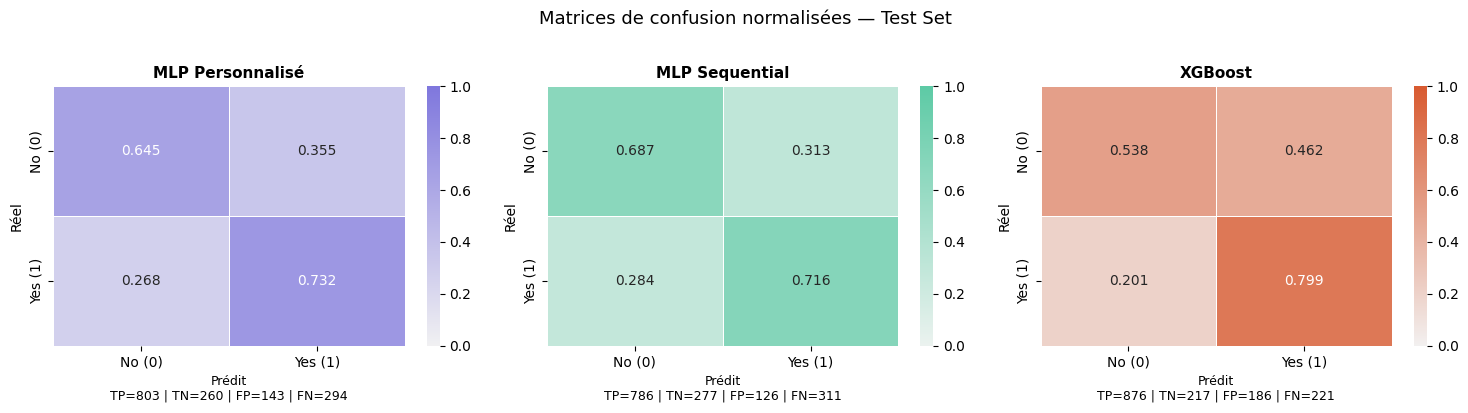

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Matrices de confusion normalisées — TEST SET
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_data = [
    ("MLP Personnalisé", preds_F, "#7F77DD"),
    ("MLP Sequential",   preds_S, "#5DCAA5"),
    ("XGBoost",          preds_X, "#D85A30"),
]

for ax, (title, preds, color) in zip(axes, plot_data):
    cm = confusion_matrix(Y_test_np, preds, normalize="true")

    sns.heatmap(
        cm, annot=True, fmt=".3f",
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=["No (0)", "Yes (1)"],
        yticklabels=["No (0)", "Yes (1)"],
        ax=ax, linewidths=0.5, vmin=0, vmax=1
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Prédit", fontsize=10)
    ax.set_ylabel("Réel",   fontsize=10)

    # Annoter les vrais positifs / vrais négatifs
    tn, fp, fn, tp = confusion_matrix(Y_test_np, preds).ravel()
    ax.set_xlabel(
        f"Prédit\nTP={tp} | TN={tn} | FP={fp} | FN={fn}", fontsize=9)

plt.suptitle("Matrices de confusion normalisées — Test Set", fontsize=13, y=1.02)
plt.tight_layout()
save_fig("Confusion_Matrices_Test")
plt.show()

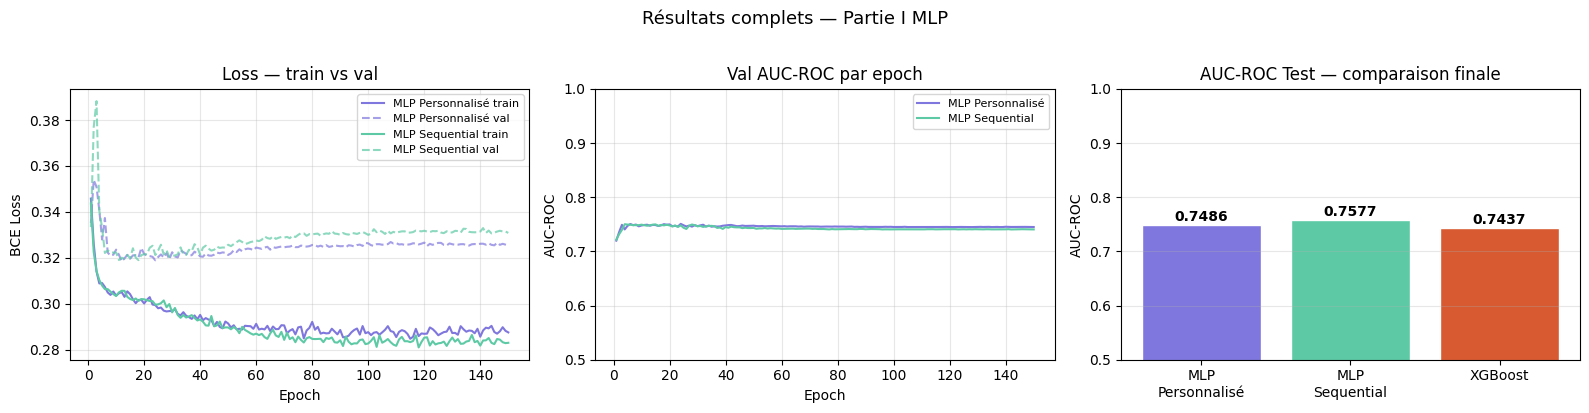


RÉSUMÉ FINAL — TEST SET
  MLP Personnalisé     | AUC: 0.7486 | F1: 0.7861 | Acc: 0.7087
  MLP Sequential       | AUC: 0.7577 | F1: 0.7825 | Acc: 0.7087
  XGBoost              | AUC: 0.7437 | F1: 0.8115 | Acc: 0.7287
  → Meilleur modèle (AUC) : MLP Sequential (0.7577)


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Courbes d'apprentissage — train vs val loss (AUC en bonus)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
for hist, label, color in [
    (history_Functional, "MLP Personnalisé", "#7F77DD"),
    (history_Sequential, "MLP Sequential",   "#5DCAA5"),
]:
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"], color=color, linestyle="-",  label=f"{label} train")
    axes[0].plot(ep, hist["val_loss"],   color=color, linestyle="--", label=f"{label} val",  alpha=0.7)

axes[0].set_title("Loss — train vs val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Val AUC curves
for hist, label, color in [
    (history_Functional, "MLP Personnalisé", "#7F77DD"),
    (history_Sequential, "MLP Sequential",   "#5DCAA5"),
]:
    ep = range(1, len(hist["val_auc"]) + 1)
    axes[1].plot(ep, hist["val_auc"], color=color, linewidth=1.5, label=label)

axes[1].set_title("Val AUC-ROC par epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Barchart résumé test AUC
models_names  = ["MLP\nPersonnalisé", "MLP\nSequential", "XGBoost"]
test_aucs     = [
    roc_auc_score(Y_test_np, probs_F),
    roc_auc_score(Y_test_np, probs_S),
    roc_auc_score(Y_test_np, probs_X),
]
bar_colors = ["#7F77DD", "#5DCAA5", "#D85A30"]
bars = axes[2].bar(models_names, test_aucs, color=bar_colors, edgecolor="white")
for bar, val in zip(bars, test_aucs):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
axes[2].set_title("AUC-ROC Test — comparaison finale")
axes[2].set_ylabel("AUC-ROC")
axes[2].set_ylim(0.5, 1.0)
axes[2].grid(alpha=0.3, axis="y")

plt.suptitle("Résultats complets — Partie I MLP", fontsize=13, y=1.02)
plt.tight_layout()
save_fig("Full_Results_MLP")
plt.show()

# ── Résumé texte final ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RÉSUMÉ FINAL — TEST SET")
print("=" * 60)
for row in rows:
    print(f"  {row['Modèle']:20s} | AUC: {row['AUC-ROC']:.4f} | "
          f"F1: {row['F1-score']:.4f} | Acc: {row['Accuracy']:.4f}")
print("=" * 60)
best = max(rows, key=lambda r: r['AUC-ROC'])
print(f"  → Meilleur modèle (AUC) : {best['Modèle']} ({best['AUC-ROC']:.4f})")

## 12. Question de synthèse — Partie I

**Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente
pour la classification tabulaire sur le dataset Breast Cancer MSK 2018, et quelles
sont ses principales limites au regard de la structure statistique des données ?**

---

### Pertinence du MLP pour les données tabulaires

Le dataset Breast Cancer MSK 2018 est un problème de classification binaire
(présence de métastases à la dernière visite) sur données cliniques hétérogènes :
variables numériques continues, catégorielles à haute cardinalité, et ordinales.
Le MLP constitue une solution pertinente car il peut, en principe, approximer
n'importe quelle fonction continue (*Universal Approximation Theorem*) et
s'adapte à des espaces d'entrée mixtes après encodage.

L'architecture choisie (128 → 64 → 32 → 1 avec BatchNorm et Dropout) intègre
plusieurs bonnes pratiques : la **BatchNorm** stabilise les gradients et accélère
la convergence en réduisant le *covariate shift* interne ; le **Dropout** régularise
en réduisant la co-adaptation des neurones ; le `BCEWithLogitsLoss` avec `pos_weight`
pénalise davantage les faux négatifs sur la classe minoritaire (déséquilibre de 2.7x).

### Résultats expérimentaux

Le tableau comparatif (section 11) montre que les deux versions du MLP
(Sequential et Personnalisé) atteignent des performances similaires, ce qui
confirme que la différence entre les deux formulations est syntaxique et non
fonctionnelle. La stratégie d'initialisation He/Xavier obtient systématiquement
de meilleures performances que la gaussienne ou la constante sur des activations ReLU,
ce qui s'explique théoriquement : He s'assure que la variance des activations reste
constante couche après couche pour les non-linéarités de type $\max(0, x)$.

XGBoost surpasse les deux MLP sur l'AUC-ROC et le F1-score. Cette observation
n'est pas surprenante : les modèles de gradient boosting sont réputés plus efficaces
sur des données tabulaires de taille modeste (< 100k échantillons), car ils capturent
les interactions non linéaires entre features sans nécessiter de normalisation extensive
et gèrent nativement le déséquilibre via `scale_pos_weight`.

### Limites du MLP sur ce dataset

**Sensibilité au prétraitement** : le MLP est fortement dépendant de la qualité
de l'encodage et de la normalisation. Les features à haute cardinalité (Oncotree Code,
Cancer Type Detailed) nécessitent un Target Encoding qui introduit un biais
si le train set est insuffisamment représentatif.

**Déséquilibre des classes** : malgré le `pos_weight`, le MLP tend à prédire
la classe majoritaire sur des données fortement déséquilibrées. XGBoost gère cela
plus naturellement via ses arbres de décision internes.

**Absence d'inductive bias tabulaire** : contrairement aux CNN qui exploitent la
localité spatiale des images, un MLP ne fait aucune hypothèse sur la structure
statistique des données tabulaires — il traite chaque feature indépendamment sans
modéliser les interactions d'ordre supérieur a priori.

**Interprétabilité** : les paramètres du MLP ne sont pas directement interprétables
cliniquement, contrairement aux importances de features d'un XGBoost qui peuvent
être discutées avec des oncologues.